# Phase 1, step 1 — Exact diagonalization (ground truth)

This notebook is the ground-truth leg of the three-way comparison. Every other method (NNQS in `02_nnqs.ipynb`, VQE in `03_vqe.ipynb`) gets checked against the numbers produced here.

**Model:** transverse-field Ising model (TFIM), open boundary conditions.

$$H = -J \sum_i Z_i Z_{i+1} \; - \; h \sum_i X_i, \qquad J = 1,\ h_c = 1$$

We use [QuSpin](https://quspin.github.io/QuSpin/) to build this Hamiltonian as a sparse matrix and find its lowest eigenvalue with the Lanczos method (`eigsh`). All the actual logic lives in `src/hamiltonian.py` and `src/exact.py` — this notebook just calls into that library and shows/plots the results, so the same code also runs headless as `python -m src.exact --config configs/exact_simulation_sweep.yaml`.

See `README.md` for why open boundary conditions were chosen and the full sweep-grid definition.

In [1]:
# Make the repo's src/ package importable from inside notebooks/
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if (Path.cwd() / ".." / "src").exists() else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json

import matplotlib.pyplot as plt
import numpy as np

from src.exact import ground_state_energy
from src.hamiltonian import build_h_grid

## Single-point sanity check

Before trusting a full sweep, check one point against a value we can hand-verify. `L=6, h=1.0` is the example used in the project roadmap itself.

In [2]:
E0 = ground_state_energy(L=6, h=1.0, J=1.0)
reference = -7.29622981

print(f"E0 = {E0:.8f}")
print(f"reference = {reference}")
assert abs(E0 - reference) < 1e-6, "exact diagonalization does not match the known reference value"
print("Matches — the Hamiltonian convention and solver are set up correctly.")

E0 = -7.29622981
reference = -7.29622981
Matches — the Hamiltonian convention and solver are set up correctly.


## Load the full simulation-track sweep

The full sweep (`L ∈ {4, 6, 8, 10, 12, 16, 20, 24}`, 21 values of `h` per `L`) is run separately as a batch job, not inline in this notebook — at `L=24` a single diagonalization takes on the order of two minutes, so the whole sweep is a background job:

```bash
python -m src.exact --config configs/exact_simulation_sweep.yaml
```

This cell just loads whatever `results/exact/{L}/{h}.json` files exist on disk. If the sweep is still running, later `L` values may be missing — rerun this cell once it's done.

In [3]:
results_dir = REPO_ROOT / "results" / "exact"

data = {}  # L -> (h_array, E0_array), sorted by h
for L_dir in sorted(results_dir.glob("*"), key=lambda p: int(p.name)):
    L = int(L_dir.name)
    points = []
    for f in L_dir.glob("*.json"):
        rec = json.loads(f.read_text())
        points.append((rec["h"], rec["E0"]))
    points.sort()
    if points:
        h_arr, e_arr = zip(*points)
        data[L] = (np.array(h_arr), np.array(e_arr))

for L, (h_arr, e_arr) in data.items():
    print(f"L={L:<3} {len(h_arr)} h-points loaded")

L=4   21 h-points loaded
L=6   21 h-points loaded
L=8   21 h-points loaded
L=10  21 h-points loaded
L=12  21 h-points loaded
L=16  21 h-points loaded
L=20  21 h-points loaded
L=24  21 h-points loaded


## Ground-state energy per site vs. h

Plotting $E_0 / L$ (energy per site, so different system sizes are comparable on one axis) against $h$. The dashed line marks the critical point $h_c = 1$. As $L$ grows, the curves should start sharpening around $h_c$ — the first hint of the finite-size scaling behavior that Phase 2 studies properly.

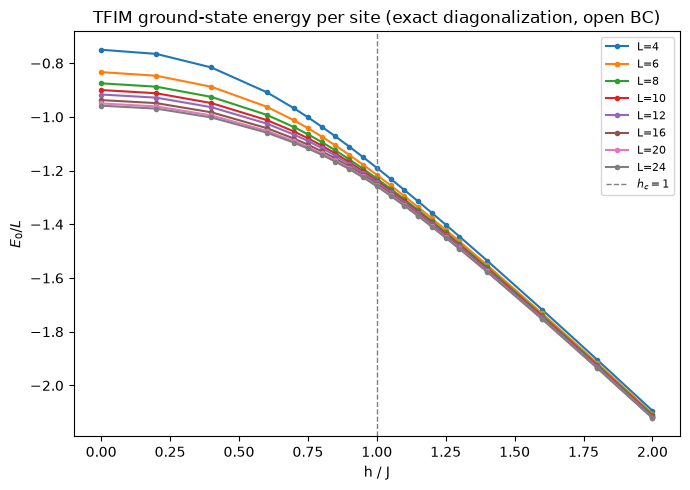

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
for L, (h_arr, e_arr) in sorted(data.items()):
    ax.plot(h_arr, e_arr / L, marker="o", markersize=3, label=f"L={L}")

ax.axvline(1.0, color="gray", linestyle="--", linewidth=1, label="$h_c = 1$")
ax.set_xlabel("h / J")
ax.set_ylabel("$E_0 / L$")
ax.set_title("TFIM ground-state energy per site (exact diagonalization, open BC)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "exact_E0_per_site_vs_h.png", dpi=150)
plt.show()

## Status and what's next

- [x] QuSpin exact diagonalization implemented and matches the roadmap's reference value
- [x] Full simulation-track sweep run (see `results/exact/`)
- [ ] **Analytic free-fermion (Jordan-Wigner) cross-check** — intentionally not done in this pass. The roadmap flags this as worth deriving carefully as its own focused step rather than rushing it alongside the main sweep, so it's parked here rather than rushed.

Next: `02_nnqs.ipynb` trains an RBM against this same Hamiltonian and checks it against these numbers.